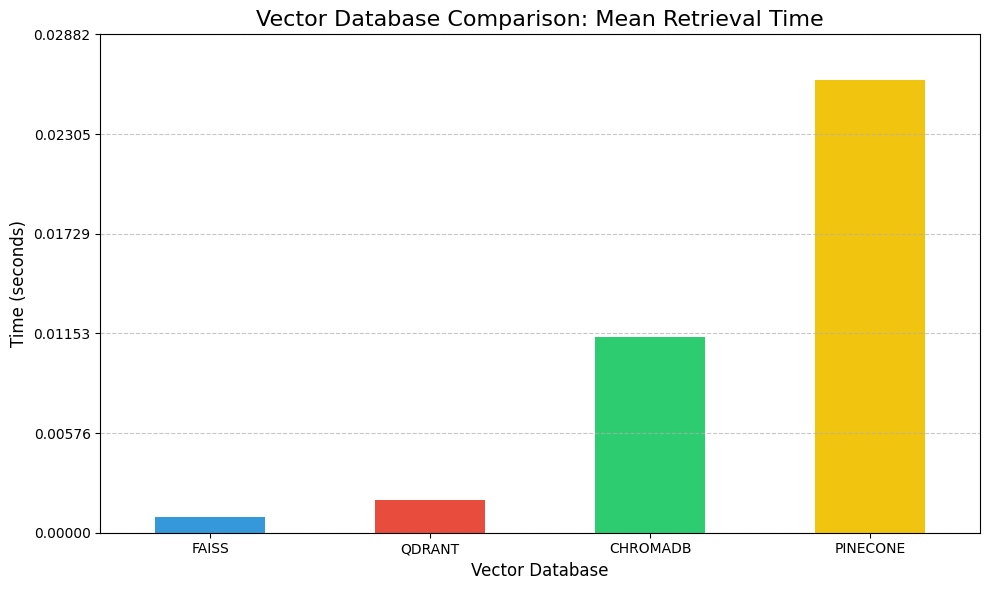

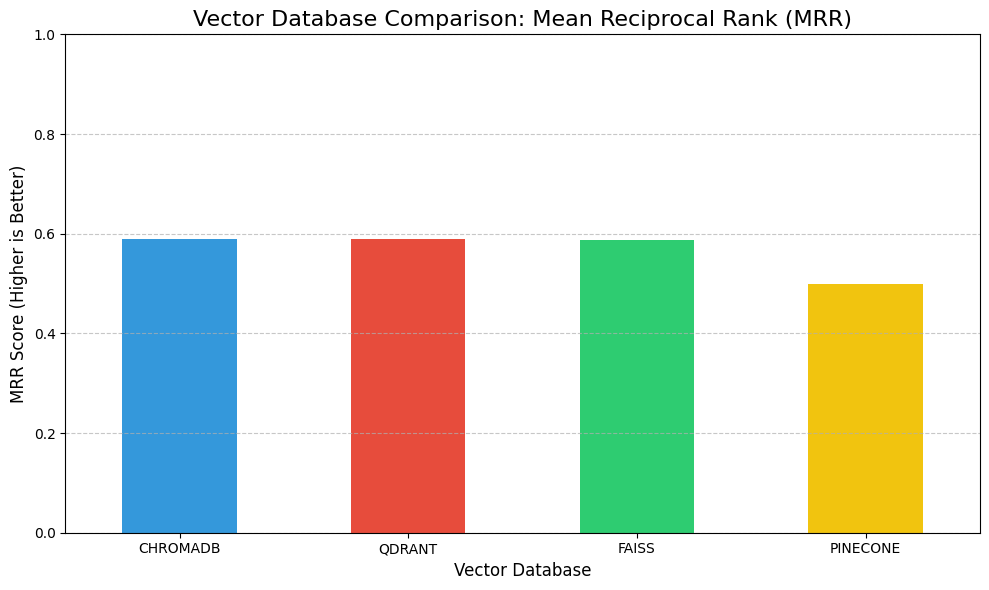

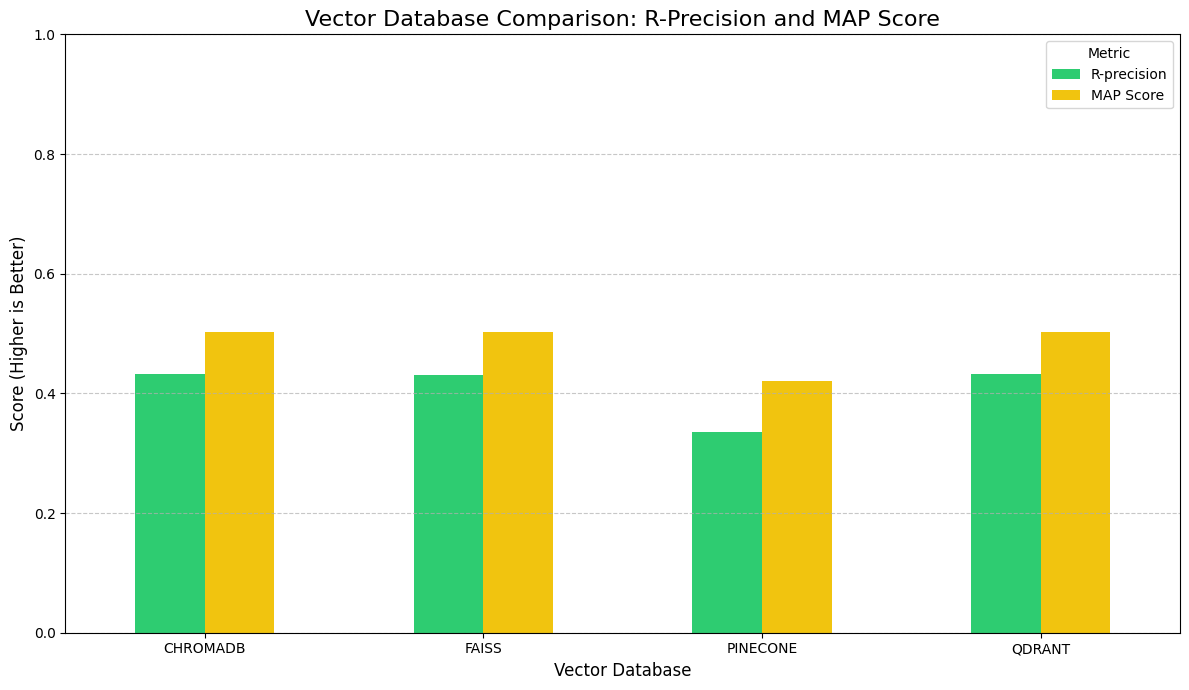

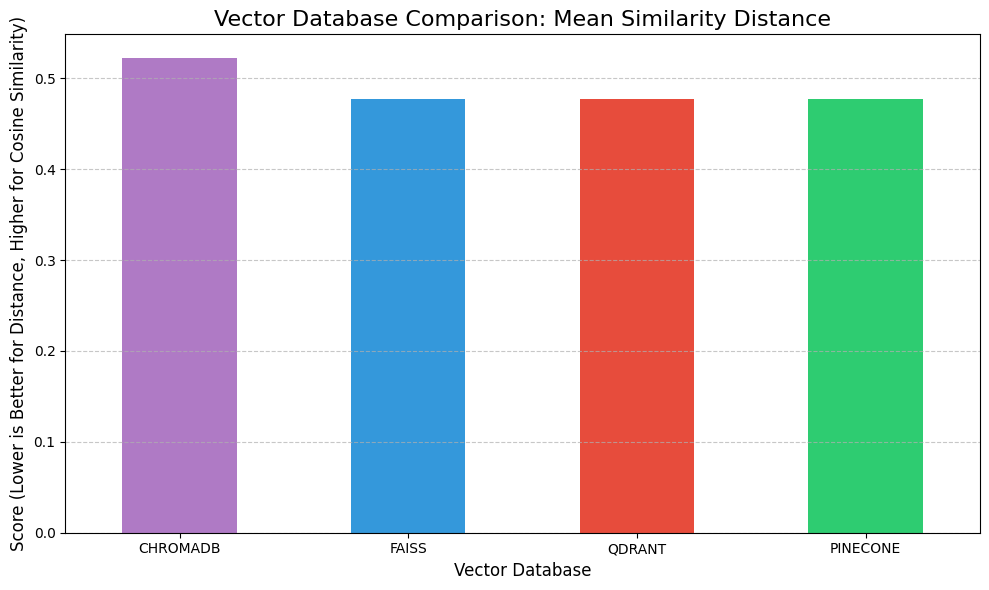

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Initial Data Structure (Placeholder) ---
# NOTE: In a real-world scenario, you should initialize this dict empty 
# and ensure all JSON files are present.
results_dict = {
    'chromadb': {}, 
    'faiss': {}, 
    'pinecone': {}, 
    'qdrant': {
        "precision_at_k": {"1": 0.5058, "3": 0.2669, "5": 0.1840, "10": 0.1133},
        "recall_at_k": {"1": 0.3648, "3": 0.5201, "5": 0.5817, "10": 0.6871},
        "map": 0.50307,
        "mrr": 0.5892,
        "ndcg": {"1": 0.5058, "3": 0.5112, "5": 0.5346, "10": 0.5721},
        "r_precision": 0.4330,
        "f1_score": {"1": 0.4039, "3": 0.3305, "5": 0.2624, "10": 0.1848},
        "mean_retrieval_time": 0.001877,
        "mean_similarity_distance": 0.4776
    }
}

# List of files to load
files_to_load = {
    'chromadb': 'chromadb_results.json',
    'faiss': 'faiss_results.json',
    'pinecone': 'pinecone_results.json',
    'qdrant': 'qdrant_results.json'
}

# --- 2. Load Data from JSON Files ---
for db_name, filepath in files_to_load.items():
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            results_dict[db_name] = json.load(f)
        # Ensure NumPy types are converted to standard float after loading,
        # in case the files were generated without the NumpyEncoder class.
        for key, value in results_dict[db_name].items():
            if isinstance(value, dict):
                # Convert list values inside sub-dictionaries if necessary (though usually not after dump)
                results_dict[db_name][key] = {
                    k: float(v) if isinstance(v, (np.floating, np.float32, float)) else v
                    for k, v in value.items()
                }
            elif isinstance(value, (np.floating, np.float32)):
                 results_dict[db_name][key] = float(value)
                 
    except FileNotFoundError:
        print(f"Warning: File not found for {db_name} at {filepath}. Skipping.")
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {filepath}. Skipping.")


# --- 3. Extract Metrics for Comparison ---
db_names = []
time_results = []
mrr_results = []
r_precision_results = []  # NEW: R-precision
map_results = []          # NEW: MAP
distance_results = []     # NEW: Mean Similarity Distance

required_keys = ['mean_retrieval_time', 'mrr', 'r_precision', 'map', 'mean_similarity_distance']

for db_name, results in results_dict.items():
    # Only include databases that were successfully loaded and have all required keys
    if results and all(key in results for key in required_keys):
        db_names.append(db_name.upper())
        time_results.append(results['mean_retrieval_time'])
        mrr_results.append(results['mrr'])
        r_precision_results.append(results['r_precision'])
        map_results.append(results['map'])
        distance_results.append(results['mean_similarity_distance'])


# Create DataFrame for Time Comparison
time_df = pd.DataFrame({'Database': db_names, 'Time (s)': time_results})
# Sort for better visualization
time_df = time_df.sort_values(by='Time (s)', ascending=True) 


# --- 4. Plot 1: Mean Retrieval Time Comparison ---
plt.figure(figsize=(10, 6))
time_df.plot(
    kind="bar",
    x='Database',
    y='Time (s)',
    ax=plt.gca(),
    legend=False,
    color=['#3498DB', '#E74C3C', '#2ECC71', '#F1C40F']
)

plt.title('Vector Database Comparison: Mean Retrieval Time', fontsize=16)
plt.xlabel('Vector Database', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.yticks(np.linspace(0, max(time_df['Time (s)']) * 1.1, 6))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 5. Plot 2: MRR Score Comparison (Accuracy Metric) ---
# Create DataFrame for MRR Comparison
mrr_df = pd.DataFrame({'Database': db_names, 'MRR Score': mrr_results})
# Sort by score for comparison
mrr_df = mrr_df.sort_values(by='MRR Score', ascending=False)

plt.figure(figsize=(10, 6))
mrr_df.plot(
    kind="bar",
    x='Database',
    y='MRR Score',
    ax=plt.gca(),
    legend=False,
    color=['#3498DB', '#E74C3C', '#2ECC71', '#F1C40F']
)

plt.title('Vector Database Comparison: Mean Reciprocal Rank (MRR)', fontsize=16)
plt.xlabel('Vector Database', fontsize=12)
plt.ylabel('MRR Score (Higher is Better)', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 6. Plot 3: R-Precision and MAP Score Comparison (Accuracy Metrics) ---
accuracy_df = pd.DataFrame({
    'Database': db_names, 
    'R-precision': r_precision_results,
    'MAP Score': map_results
})

plt.figure(figsize=(12, 7))
accuracy_df.set_index('Database').plot(
    kind='bar',
    ax=plt.gca(),
    color=['#2ECC71', '#F1C40F']
)

plt.title('Vector Database Comparison: R-Precision and MAP Score', fontsize=16)
plt.xlabel('Vector Database', fontsize=12)
plt.ylabel('Score (Higher is Better)', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.ylim(0, 1.0) 
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 7. Plot 4: Mean Similarity Distance Comparison ---
distance_df = pd.DataFrame({'Database': db_names, 'Mean Similarity Distance': distance_results})
# We sort descendingly, but remember that a low distance is better (for distance metrics)
distance_df = distance_df.sort_values(by='Mean Similarity Distance', ascending=False) 

plt.figure(figsize=(10, 6))
distance_df.plot(
    kind="bar",
    x='Database',
    y='Mean Similarity Distance',
    ax=plt.gca(),
    legend=False,
    color=['#AF7AC5', '#3498DB', '#E74C3C', '#2ECC71']
)

plt.title('Vector Database Comparison: Mean Similarity Distance', fontsize=16)
plt.xlabel('Vector Database', fontsize=12)
plt.ylabel('Score (Lower is Better for Distance, Higher for Cosine Similarity)', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
